In [32]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import torch
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from datetime import datetime

from prism.config import PROCESSED_DATA_DIR, MODELS_DIR
from prism.PRiSM_functions import normalise, modelStats
from prism.maskedmlp import train_mlp_batched, mlpmask_pytorch, generate_mask
from prism.save_models import save_mlp, save_lasso, save_prn
from prism.prlasso import prLASSO
from prism.partial_responses import partial_responses
from prism.nomogram import nomogram


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
%reload_ext autoreload

In [6]:
# Parameters
device = 'cpu'
method = 'dirac'
SAVE_MODELS = False
seed = 257

np.random.seed(seed)
torch.manual_seed(seed)

# Import data


In [9]:
data_train = pd.read_csv(PROCESSED_DATA_DIR.joinpath('imputed_dataset1_train.csv'))
data_test = pd.read_csv(PROCESSED_DATA_DIR.joinpath('imputed_dataset1_test.csv'))
data_val = pd.read_csv(PROCESSED_DATA_DIR.joinpath('imputed_dataset1_val.csv'))

data_train_test = pd.concat([data_train, data_test])

# Drop id column
data_train.drop('trr_id_code', axis=1, inplace=True)
data_test.drop('trr_id_code', axis=1, inplace=True)
data_val.drop('trr_id_code', axis=1, inplace=True)

target_col = 'oneyearmort'

x_train0 = data_train.drop(target_col, axis=1)
y_train = data_train[target_col]

x_test0 = data_test.drop(target_col, axis=1)
y_test = data_test[target_col]

x_val0 = data_val.drop(target_col, axis=1)
y_val = data_val[target_col]

[x_train, x_test] = normalise(x_train0, x_test0)
x_val = normalise(x_val0)

x_train_tensor = torch.tensor(x_train.values, dtype=torch.float32, device=device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test.values, dtype=torch.float32, device=device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)
x_val_tensor = torch.tensor(x_val.values, dtype=torch.float32, device=device)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)


# Train MLP


In [14]:
mlp_params = {
    'n_hidden': 10,
    'weight_decay': 1e-5,
    'lr': 0.001,
    'patience': 50,
    'tolerance': 0.0001,
    'batch_size': 1024,
    'device': device,
    'seed': seed
}

mlp_batched = train_mlp_batched(x_train, y_train, x_test, y_test, **mlp_params)

Epoch 0: Train loss 0.6690, Val loss 0.6166
Epoch 1: Train loss 0.5749, Val loss 0.5303
Epoch 2: Train loss 0.5062, Val loss 0.4680
Epoch 3: Train loss 0.4573, Val loss 0.4224
Epoch 4: Train loss 0.4240, Val loss 0.3906
Epoch 5: Train loss 0.4014, Val loss 0.3693
Epoch 6: Train loss 0.3869, Val loss 0.3563
Epoch 7: Train loss 0.3782, Val loss 0.3485
Epoch 8: Train loss 0.3726, Val loss 0.3440
Epoch 9: Train loss 0.3694, Val loss 0.3416
Epoch 10: Train loss 0.3667, Val loss 0.3402
Epoch 11: Train loss 0.3653, Val loss 0.3395
Epoch 12: Train loss 0.3644, Val loss 0.3393
Epoch 13: Train loss 0.3640, Val loss 0.3392
Epoch 14: Train loss 0.3631, Val loss 0.3391
Epoch 15: Train loss 0.3621, Val loss 0.3391
Epoch 16: Train loss 0.3624, Val loss 0.3392
Epoch 17: Train loss 0.3617, Val loss 0.3392
Epoch 18: Train loss 0.3613, Val loss 0.3393
Epoch 19: Train loss 0.3611, Val loss 0.3392
Epoch 20: Train loss 0.3611, Val loss 0.3393
Epoch 21: Train loss 0.3608, Val loss 0.3394
Epoch 22: Train loss

# Evaluate MLP

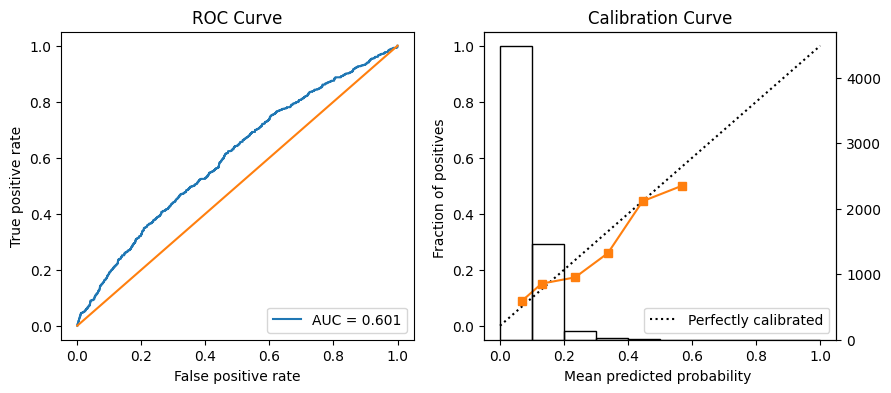


-------- Metrics --------
prevalence: 0.123
sensitivity: 0.241
specificity: 0.864
accuracy: 0.797
ppv: 0.175
auc score: 0.601
auc lower ci: 0.577
auc upper ci: 0.626
-------------------------


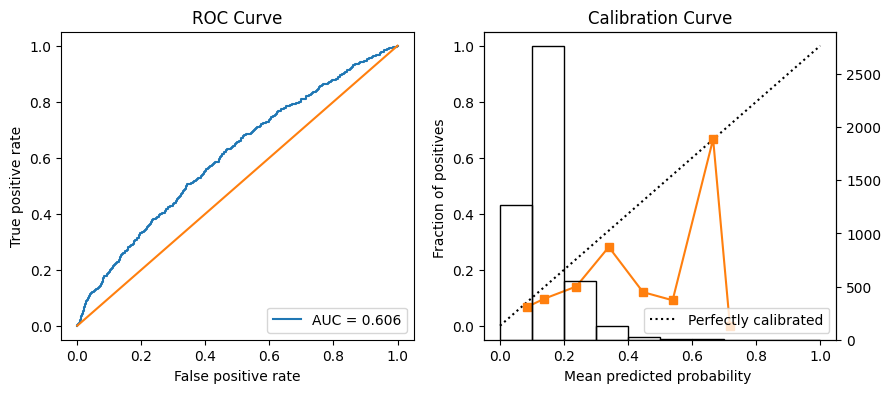


-------- Metrics --------
prevalence: 0.123
sensitivity: 0.667
specificity: 0.489
accuracy: 0.507
ppv: 0.126
auc score: 0.606
auc lower ci: 0.581
auc upper ci: 0.636
-------------------------


{'prevalence': 0.123,
 'sensitivity': 0.667,
 'specificity': 0.489,
 'accuracy': 0.507,
 'ppv': 0.126,
 'auc score': 0.606,
 'auc lower ci': '0.581',
 'auc upper ci': '0.636'}

In [15]:
y_test_blackbox = mlp_batched.predict(x_test_tensor).cpu().numpy()
y_val_blackbox = mlp_batched.predict(x_val_tensor).cpu().numpy()

mlp_metrics_test = modelStats(y_test_blackbox, y_test, y_train, ROC=True, mdlCalibration=True, metricNames=True, auc_ci=True)
modelStats(y_val_blackbox, y_val, y_train, ROC=True, mdlCalibration=True, metricNames=True, auc_ci=True)

In [8]:
# Save MLP
if SAVE_MODELS:
    save_mlp(mlp_batched, mlp_params, mlp_metrics_test, MODELS_DIR)


# MLP LASSO

In [16]:
partial_responses_train, partial_responses_test, bivariate_inputs = partial_responses(
    x_train_tensor,
    x_test_tensor,
    mlp_batched,
    method=method,
    device=device
)

# Run LASSO on MLP Partial Responses

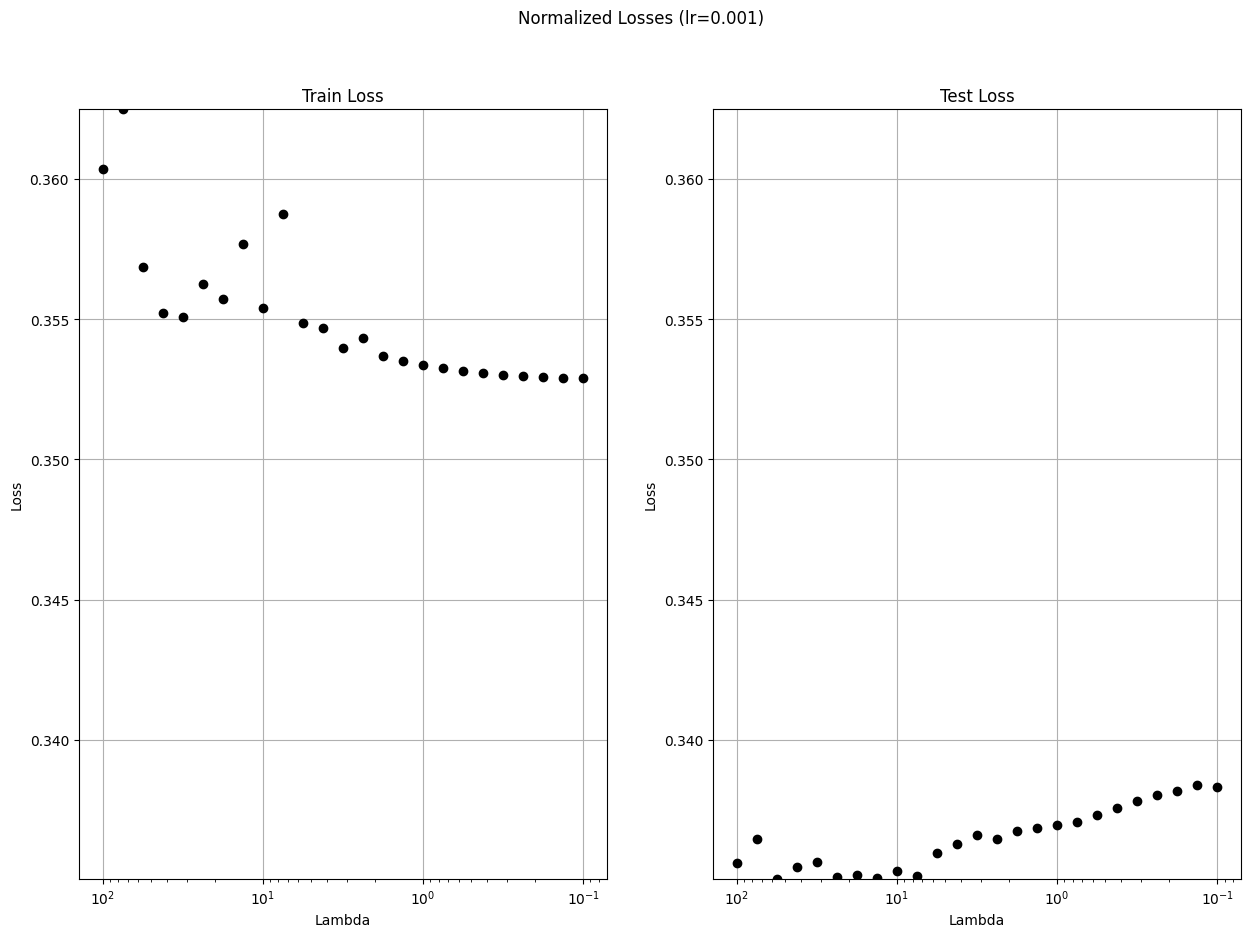

23 - Lambda 0.13335: Test AUC 0.5976, n_univ: 10, n_biv: 46
 0 - Lambda 100.00000: Train AUC 0.6179, Train Deviance 22702.7541, Test AUC 0.5778, Test Deviance 4118.1220, n_univ: 4, n_biv: 0
    -> Within 1 SD of maximum Test AUC
 1 - Lambda 74.98942: Train AUC 0.6322, Train Deviance 22568.0478, Test AUC 0.5881, Test Deviance 4107.8370, n_univ: 6, n_biv: 0
 2 - Lambda 56.23413: Train AUC 0.6395, Train Deviance 22468.4755, Test AUC 0.5943, Test Deviance 4102.2627, n_univ: 6, n_biv: 0
 3 - Lambda 42.16965: Train AUC 0.6433, Train Deviance 22402.3354, Test AUC 0.5968, Test Deviance 4101.2200, n_univ: 7, n_biv: 0
 4 - Lambda 31.62278: Train AUC 0.6461, Train Deviance 22350.5520, Test AUC 0.5994, Test Deviance 4100.7691, n_univ: 8, n_biv: 0
    -> Minimum Test Deviance at this lambda
 5 - Lambda 23.71374: Train AUC 0.6481, Train Deviance 22312.3465, Test AUC 0.6006, Test Deviance 4101.4960, n_univ: 8, n_biv: 1
 6 - Lambda 17.78279: Train AUC 0.6500, Train Deviance 22279.3365, Test AUC 0.6014

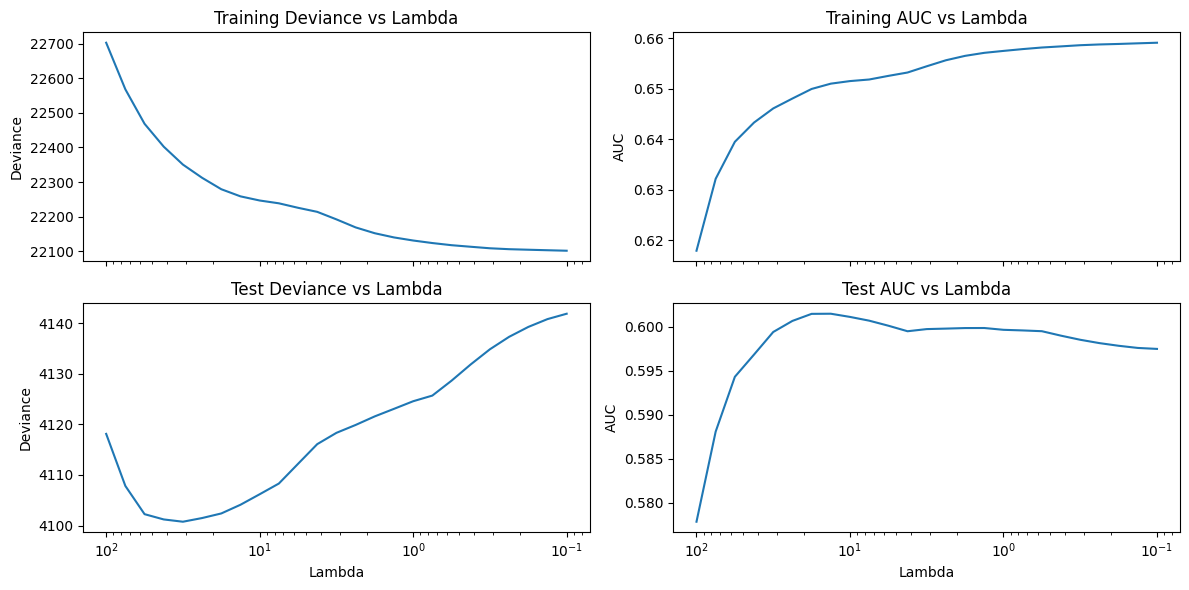

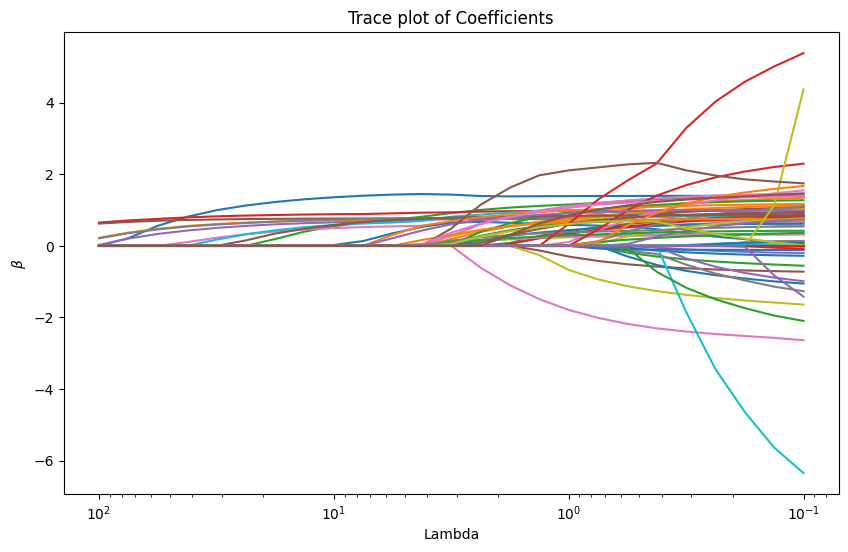

In [17]:
num_lambdas = 25
verbose = True
lambdas, betas, trainAUC, testAUC, trainDev, testDev, glmPred = prLASSO(partial_responses_train, partial_responses_test, y_train, y_test, num_lambdas=num_lambdas, log_min_lambda=-1, verbose=verbose)

In [18]:
# Note: The selectLambda function is not available in the new implementation.
# We'll need to manually select a lambda value or implement a new selection method.
userLambda = 7  # This is now manually set
print(f"Selected lambda: {lambdas[userLambda]}")

Selected lambda: 13.33521432163324


# Plots of the MLP partial responses for the selected lambda

C:\Users\Henry Pigot\Documents\MEGAsync\2024 post doc\explainable survival prediction model\prism_github\prism\partial_responses.py:164: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at ..\aten\src\ATen/native/BucketizationUtils.h:34.)
  - univariate_responses[i][torch.searchsorted(x_subset_i, x_ij[:, 0])]


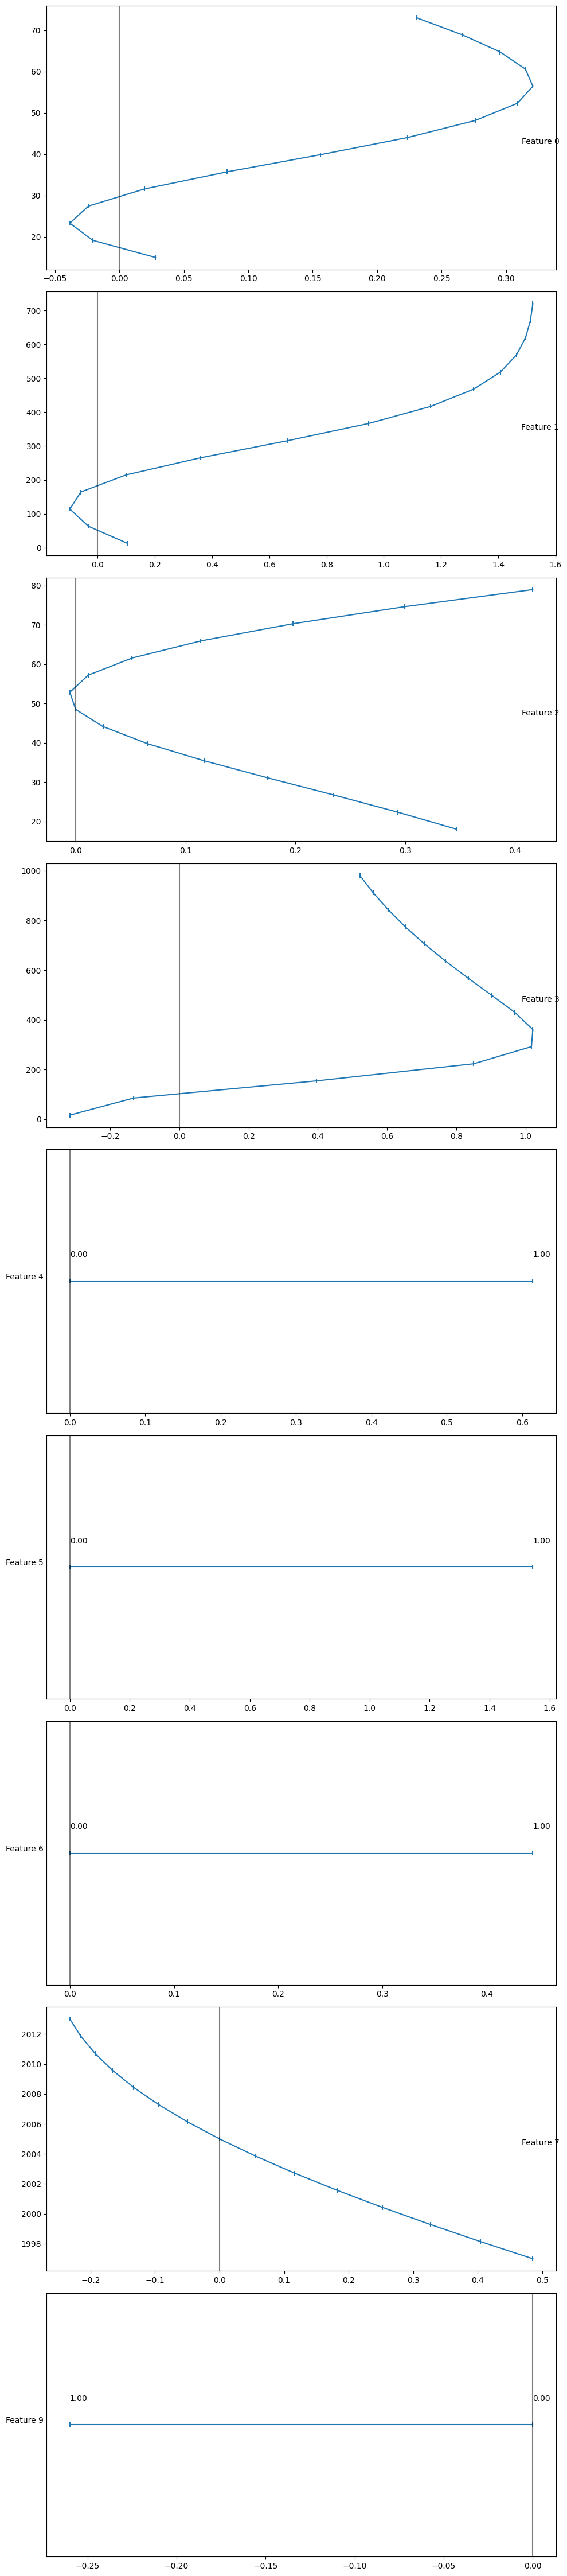

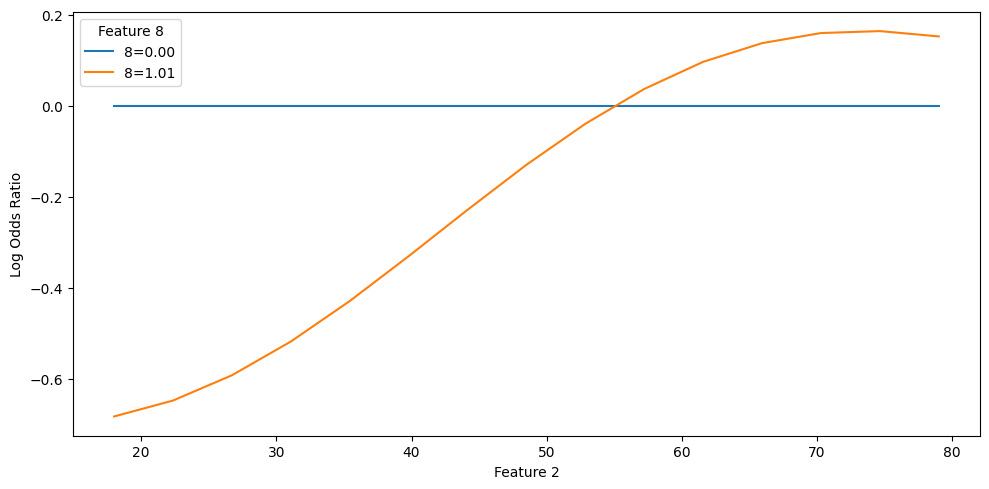

([tensor([ 0.0280, -0.0206, -0.0384, -0.0240,  0.0195,  0.0836,  0.1560,  0.2235,
           0.2761,  0.3087,  0.3208,  0.3150,  0.2954,  0.2661,  0.2306]),
  tensor([ 0.1039, -0.0326, -0.0975, -0.0590,  0.0997,  0.3603,  0.6652,  0.9467,
           1.1644,  1.3134,  1.4075,  1.4635,  1.4953,  1.5124,  1.5211]),
  tensor([ 3.4693e-01,  2.9323e-01,  2.3501e-01,  1.7502e-01,  1.1697e-01,
           6.5291e-02,  2.4756e-02, -6.6280e-05, -5.3811e-03,  1.1381e-02,
           5.1306e-02,  1.1398e-01,  1.9766e-01,  2.9957e-01,  4.1625e-01]),
  tensor([-0.3165, -0.1325,  0.3952,  0.8496,  1.0169,  1.0209,  0.9689,  0.9022,
           0.8340,  0.7686,  0.7078,  0.6524,  0.6029,  0.5592,  0.5211]),
  tensor([0.0000, 0.6142]),
  tensor([0.0000, 1.5440]),
  tensor([0.0000, 0.4444]),
  tensor([ 0.4854,  0.4046,  0.3267,  0.2524,  0.1821,  0.1163,  0.0555,  0.0000,
          -0.0500, -0.0943, -0.1328, -0.1657, -0.1930, -0.2150, -0.2320]),
  tensor([ 0.0000, -0.1870]),
  tensor([ 0.0000, -0.2599]),
 

In [19]:
# Note: The prPlots function is not yet available in the new implementation.
# We'll use the new nomogram function instead.
nomogram(
    torch.tensor(betas),
    userLambda,
    torch.tensor(x_train.values, dtype=torch.float32),
    torch.tensor(x_train0.median().values, dtype=torch.float32),
    torch.tensor(x_train0.std().values, dtype=torch.float32),
    mlp_batched,
    n_steps=15,
    sd_scale=2,
    method=method,
    device=device,
    categorical_threshold=15
)

# Train the Partial Response Network

['donage', 'donischemictimeminutes', 'recageyear', 'reccreatininemostrecent', 'recinfections2weeks', 'recventilator', 'recsex', 'tx_year', 'diagnNICM', 'recageyear : diagnICM']


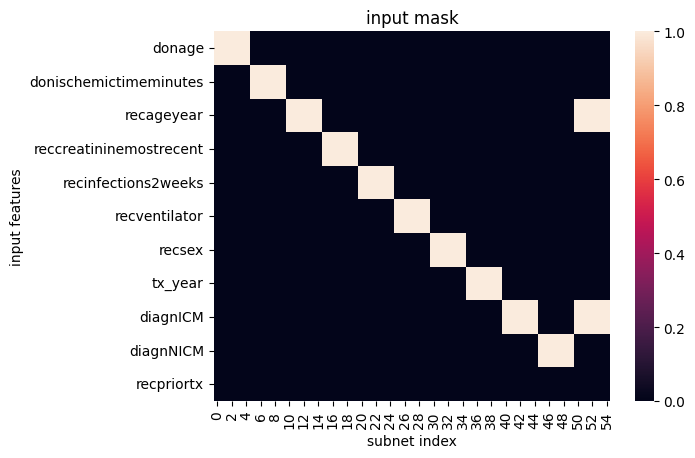

Epoch 0, Training loss 0.7491949796676636, Validation loss 0.5058018565177917
Epoch 1, Training loss 0.5208706855773926, Validation loss 0.3845042586326599
Epoch 2, Training loss 0.4087001085281372, Validation loss 0.34338873624801636
Epoch 3, Training loss 0.3777748942375183, Validation loss 0.3566133677959442
Epoch 4, Training loss 0.3964877128601074, Validation loss 0.38072434067726135
Epoch 5, Training loss 0.42082342505455017, Validation loss 0.39131689071655273
Epoch 6, Training loss 0.4279251992702484, Validation loss 0.38494932651519775
Epoch 7, Training loss 0.41638851165771484, Validation loss 0.36732038855552673
Epoch 8, Training loss 0.39412549138069153, Validation loss 0.34791669249534607
Epoch 9, Training loss 0.3729674220085144, Validation loss 0.33749744296073914
Epoch 10, Training loss 0.3656228184700012, Validation loss 0.34155094623565674
Epoch 11, Training loss 0.37698012590408325, Validation loss 0.3493284285068512
Epoch 12, Training loss 0.39084920287132263, Valid

In [25]:
mask, nPr = generate_mask(betas, userLambda, x_train, bivariate_inputs, include_bivariate_as_univariate=True)

prn_params = {
    'n_hidden': nPr,
    'mask': mask,
    'subnet_nodes': 5,
    'iter': 10000,
    'lr': 0.05,
    'weight_decay': 0.00001,
    'tolerance': 0.0001,
    'patience': 100,
    'device': device,
    'seed': seed
}

prn = mlpmask_pytorch(x_train, y_train, x_test, y_test, **prn_params)

# Evaluate the Partial Response Network

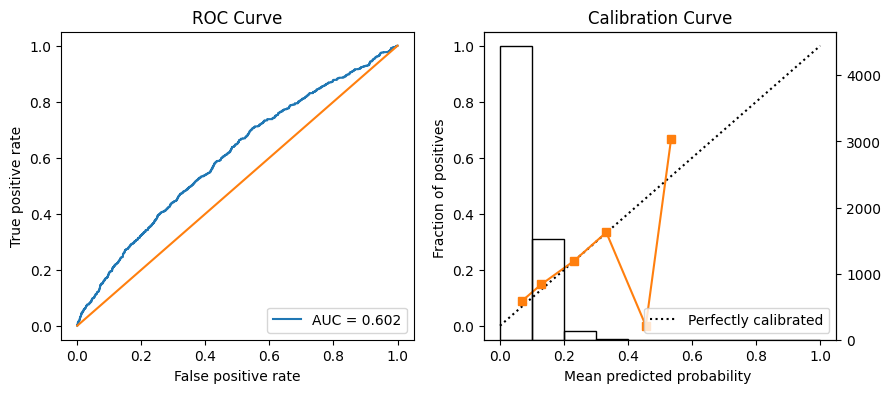


-------- Metrics --------
prevalence: 0.123
sensitivity: 0.235
specificity: 0.867
accuracy: 0.799
ppv: 0.174
auc score: 0.602
auc lower ci: 0.578
auc upper ci: 0.63
-------------------------


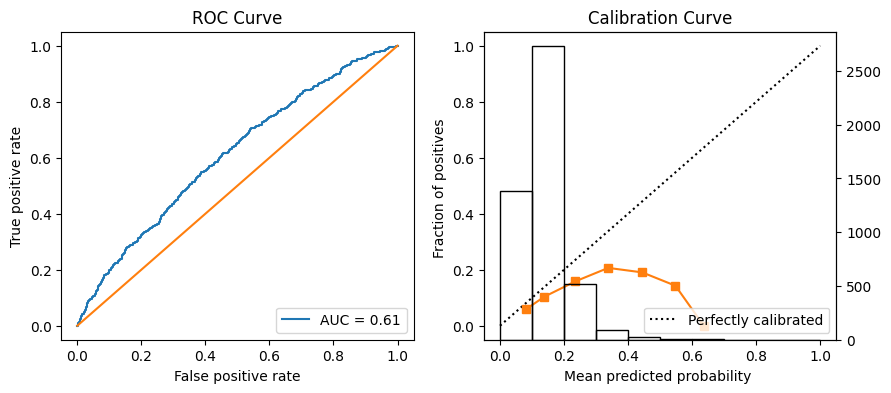


-------- Metrics --------
prevalence: 0.123
sensitivity: 0.639
specificity: 0.512
accuracy: 0.524
ppv: 0.126
auc score: 0.61
auc lower ci: 0.585
auc upper ci: 0.636
-------------------------


{'prevalence': 0.123,
 'sensitivity': 0.639,
 'specificity': 0.512,
 'accuracy': 0.524,
 'ppv': 0.126,
 'auc score': 0.61,
 'auc lower ci': '0.585',
 'auc upper ci': '0.636'}

In [26]:
y_test_prn_pytorch = prn.predict(x_test_tensor, device=device).cpu().numpy()
y_val_prn_pytorch = prn.predict(x_val_tensor, device=device).cpu().numpy()

prn_metrics_test = modelStats(y_test_prn_pytorch, y_test, y_train, auc_ci=True)
modelStats(y_val_prn_pytorch, y_val, y_train, auc_ci=True)

In [ ]:
if SAVE_MODELS:
    save_prn(prn, prn_params, prn_metrics_test, MODELS_DIR)

# LASSO on the Partial Response Network

In [29]:
# Use the new partial_responses function for PRN
partial_responses_train_prn, partial_responses_test_prn, bivariate_inputs_prn = partial_responses(
    x_train_tensor,
    x_test_tensor,
    prn,
    method=method,
    device=device
)

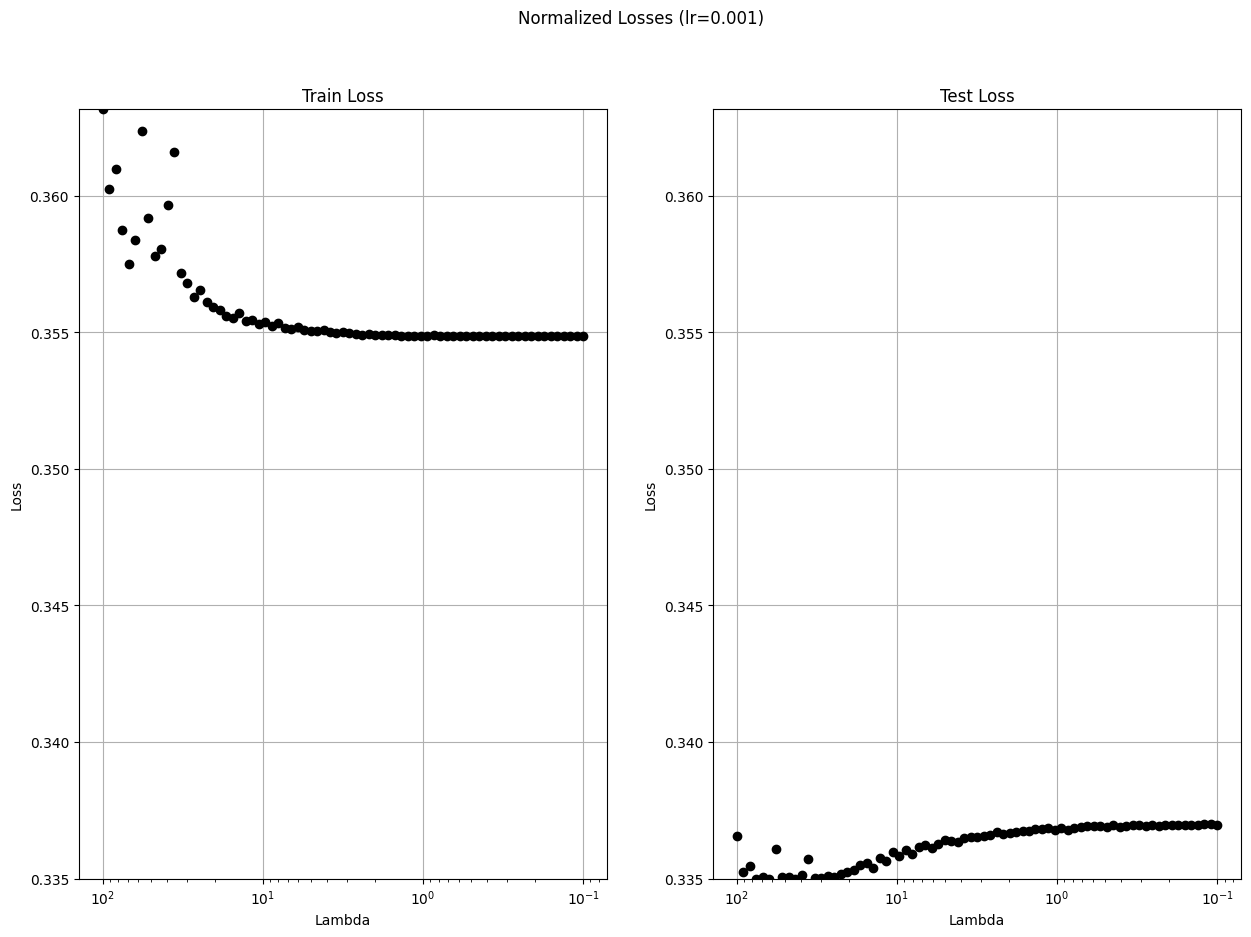

72 - Lambda 0.12053: Test AUC 0.6018, n_univ: 10, n_biv: 1
 0 - Lambda 100.00000: Train AUC 0.6168, Train Deviance 22745.3329, Test AUC 0.5818, Test Deviance 4119.2754, n_univ: 4, n_biv: 0
    -> Within 1 SD of maximum Test AUC
 1 - Lambda 91.08764: Train AUC 0.6228, Train Deviance 22694.6960, Test AUC 0.5853, Test Deviance 4113.8151, n_univ: 4, n_biv: 0
 2 - Lambda 82.96959: Train AUC 0.6276, Train Deviance 22647.3027, Test AUC 0.5883, Test Deviance 4109.3422, n_univ: 5, n_biv: 0
    -> Within 1 SD of minimum Test Deviance
 3 - Lambda 75.57504: Train AUC 0.6309, Train Deviance 22606.9482, Test AUC 0.5903, Test Deviance 4106.2040, n_univ: 5, n_biv: 0
 4 - Lambda 68.83952: Train AUC 0.6346, Train Deviance 22562.7209, Test AUC 0.5929, Test Deviance 4103.4899, n_univ: 5, n_biv: 0
 5 - Lambda 62.70430: Train AUC 0.6371, Train Deviance 22526.1738, Test AUC 0.5944, Test Deviance 4101.8651, n_univ: 6, n_biv: 0
 6 - Lambda 57.11586: Train AUC 0.6387, Train Deviance 22495.9789, Test AUC 0.5954,

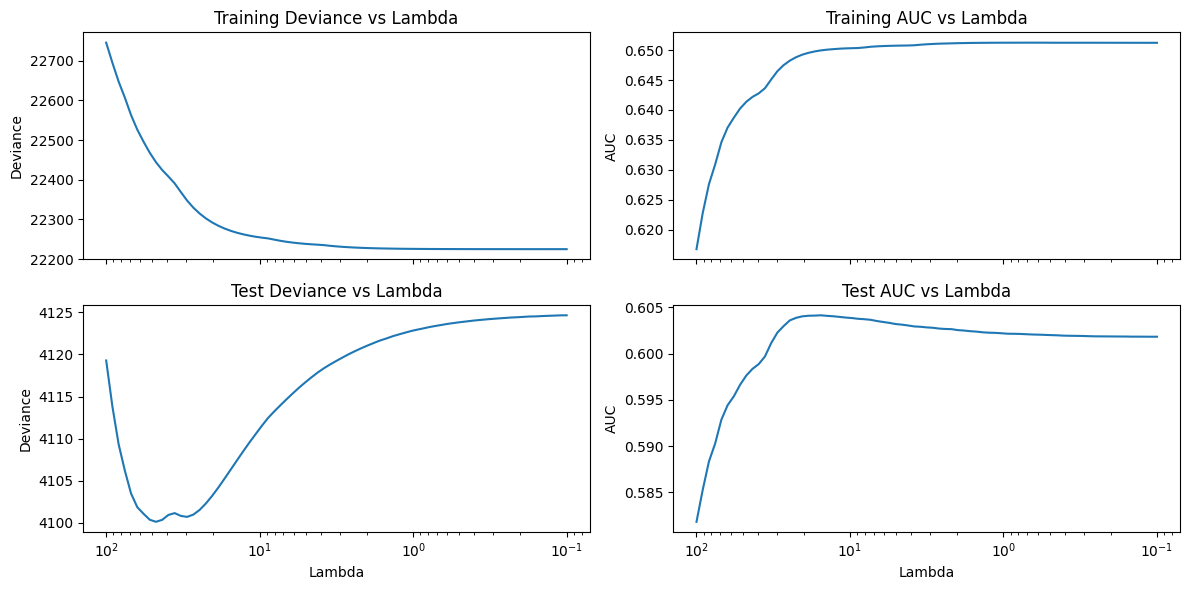

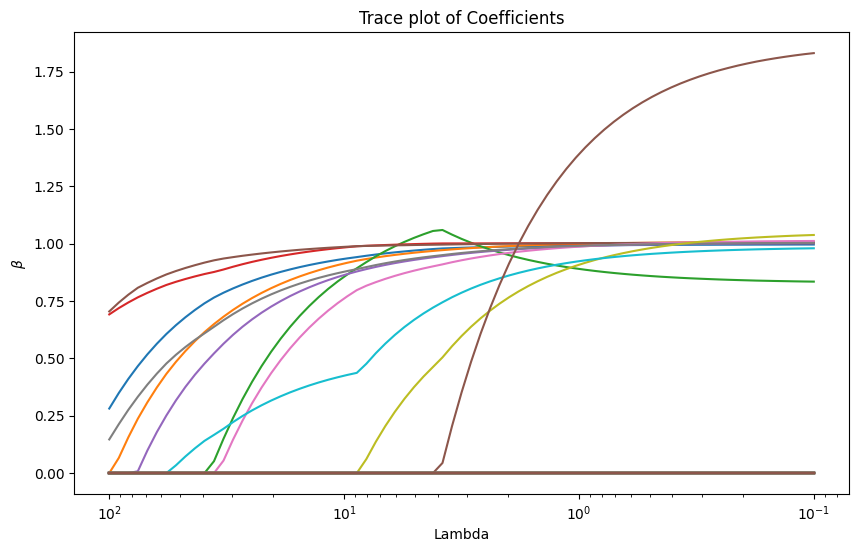

In [30]:
lambdas_prn, betas_prn, trainAUC_prn, testAUC_prn, trainDev_prn, testDev_prn, glmPred_prn = prLASSO(partial_responses_train_prn, partial_responses_test_prn, y_train, y_test, num_lambdas=75, log_max_lambda=2, log_min_lambda=-1, verbose=True)

In [31]:
# Note: userLambda_prn selection is not available yet in the new implementation.
# We'll need to manually select a lambda value.
userLambda_prn = 40  # This is now manually set
print(f"Selected PRN lambda: {lambdas_prn[userLambda_prn]}")

Selected PRN lambda: 2.389892566231049


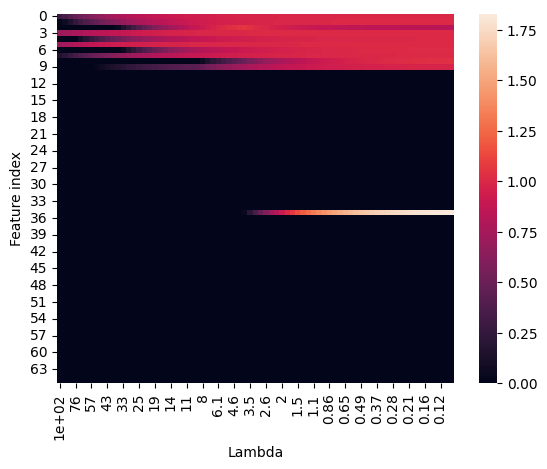

In [34]:
ax = sns.heatmap(betas_prn, xticklabels=lambdas_prn)
ax.set_xticklabels(["{:.2g}".format(x) for x in lambdas_prn], rotation=90)
ax.set_xlabel('Lambda')
ax.set_ylabel('Feature index')

# reduce number of xtick labels
ax.set_xticks(ax.get_xticks()[::3]);

# Validation inference

In [35]:
partial_responses_train_prn, partial_responses_val_prn, _ = partial_responses(
    torch.tensor(x_train.values, dtype=torch.float32),
    torch.tensor(x_val.values, dtype=torch.float32),
    prn,
    method=method,
    device=device
)

lasso_params = {
    'C': 1/lambdas_prn[userLambda_prn],
    'penalty': 'l1',
    'solver': 'saga',
    'max_iter': 10000
}

prn_lasso = LogisticRegression(**lasso_params)
prn_lasso.fit(partial_responses_train_prn, y_train.to_numpy().ravel())

LogisticRegression(C=0.4184288507901583, max_iter=10000, penalty='l1',
                   solver='saga')

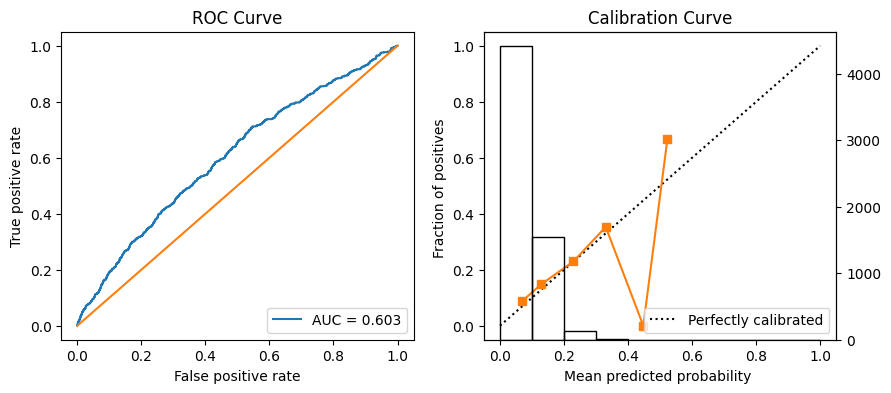


-------- Metrics --------
prevalence: 0.123
sensitivity: 0.238
specificity: 0.867
accuracy: 0.8
ppv: 0.177
auc score: 0.603
auc lower ci: 0.581
auc upper ci: 0.627
-------------------------


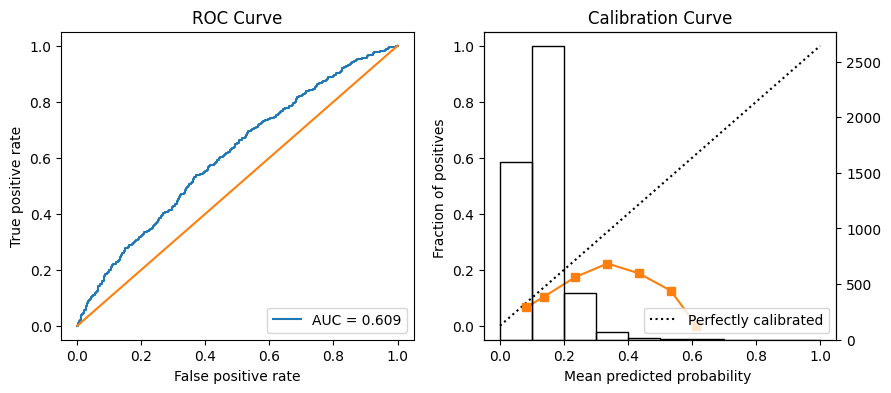


-------- Metrics --------
prevalence: 0.123
sensitivity: 0.594
specificity: 0.558
accuracy: 0.561
ppv: 0.129
auc score: 0.609
auc lower ci: 0.587
auc upper ci: 0.637
-------------------------


{'prevalence': 0.123,
 'sensitivity': 0.594,
 'specificity': 0.558,
 'accuracy': 0.561,
 'ppv': 0.129,
 'auc score': 0.609,
 'auc lower ci': '0.587',
 'auc upper ci': '0.637'}

In [36]:
y_pred_test_prn_lasso = prn_lasso.predict_proba(partial_responses_test_prn)[:, 1]
y_pred_val_prn_lasso = prn_lasso.predict_proba(partial_responses_val_prn)[:, 1]
lasso_metrics_test = modelStats(y_pred_test_prn_lasso, y_test, y_train, auc_ci=True)
modelStats(y_pred_val_prn_lasso, y_val, y_train, auc_ci=True)

In [ ]:
if SAVE_MODELS:
    save_lasso(prn_lasso, lasso_params, lasso_metrics_test, MODELS_DIR)

In [ ]:
# Partial Response Network Nomogram

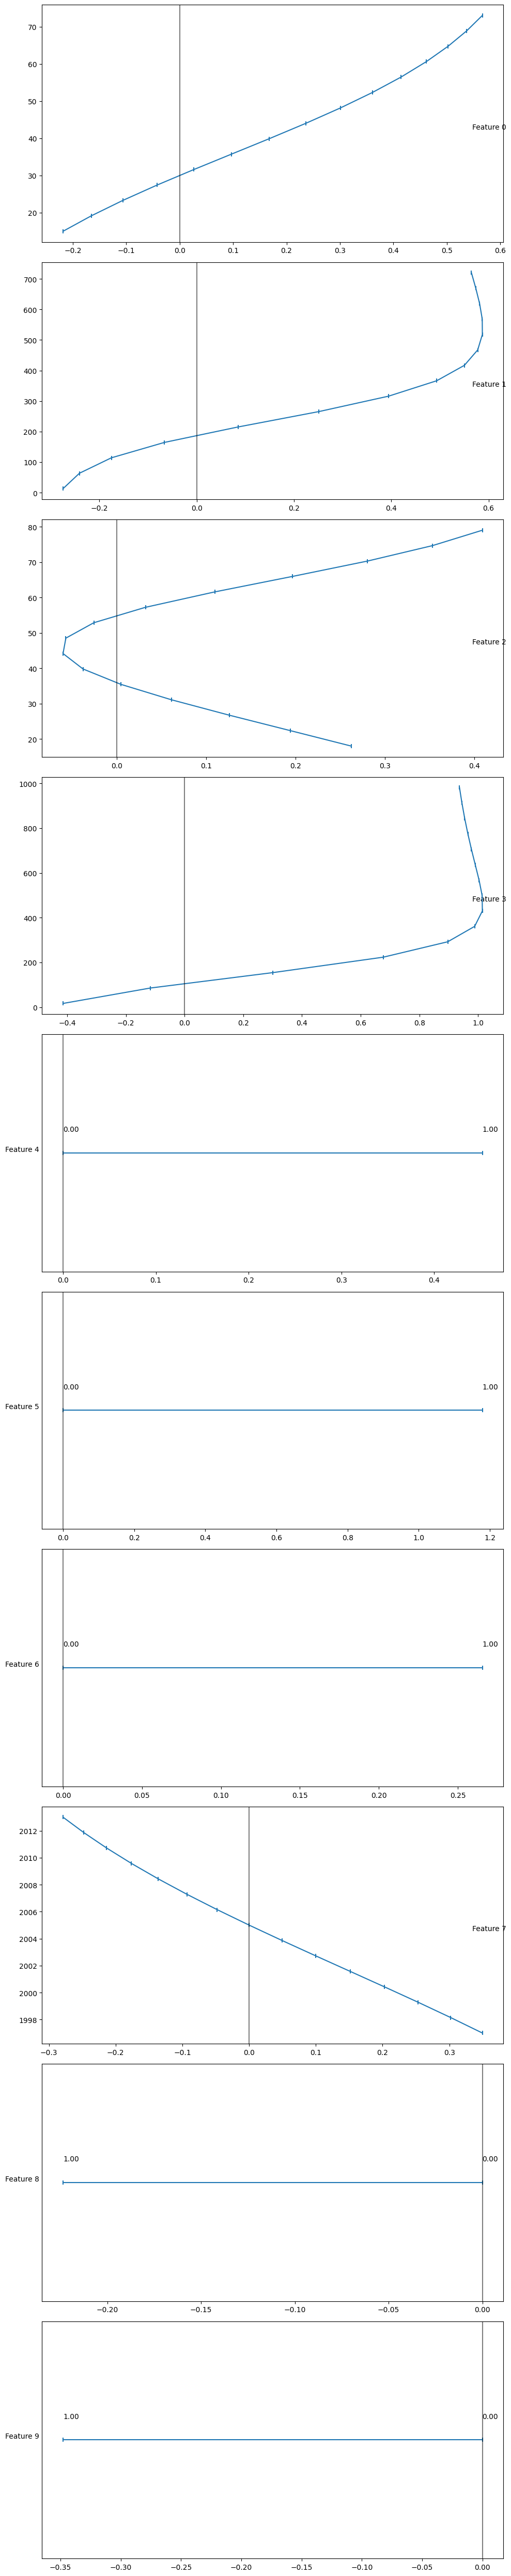

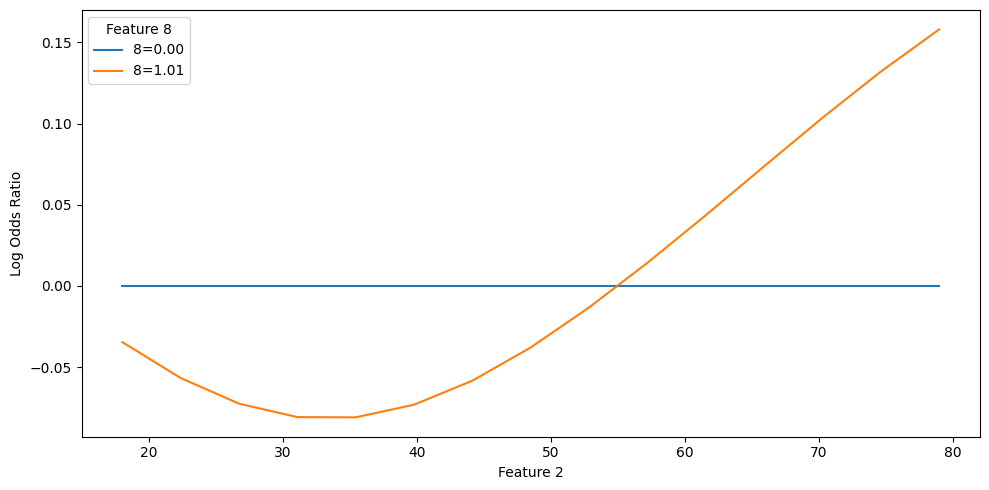

([tensor([-0.2183, -0.1654, -0.1064, -0.0420,  0.0263,  0.0967,  0.1673,  0.2360,
           0.3009,  0.3606,  0.4143,  0.4615,  0.5023,  0.5372,  0.5665]),
  tensor([-0.2746, -0.2408, -0.1753, -0.0661,  0.0850,  0.2513,  0.3946,  0.4934,
           0.5503,  0.5777,  0.5872,  0.5870,  0.5816,  0.5737,  0.5648]),
  tensor([ 0.2623,  0.1943,  0.1262,  0.0615,  0.0050, -0.0375, -0.0599, -0.0567,
          -0.0254,  0.0324,  0.1099,  0.1965,  0.2807,  0.3533,  0.4092]),
  tensor([-0.4142, -0.1166,  0.3010,  0.6768,  0.8966,  0.9883,  1.0145,  1.0138,
           1.0034,  0.9903,  0.9772,  0.9652,  0.9544,  0.9449,  0.9367]),
  tensor([0.0000, 0.4521]),
  tensor([0.0000, 1.1790]),
  tensor([0.0000, 0.2655]),
  tensor([ 0.3495,  0.3022,  0.2530,  0.2025,  0.1514,  0.1001,  0.0495,  0.0000,
          -0.0477, -0.0932, -0.1362, -0.1763, -0.2134, -0.2476, -0.2788]),
  tensor([ 0.0000, -0.2236]),
  tensor([ 0.0000, -0.3478]),
  tensor([0., 0.])],
 [tensor([ 2.3842e-07,  0.0000e+00,  2.3842e-07,  

In [37]:
nomogram(
    torch.tensor(betas_prn),
    userLambda_prn,
    torch.tensor(x_train.values, dtype=torch.float32),
    torch.tensor(x_train0.median().values, dtype=torch.float32),
    torch.tensor(x_train0.std().values, dtype=torch.float32),
    prn,
    n_steps=15,
    sd_scale=2,
    method=method,
    device=device,
    categorical_threshold=15
)